In [1]:
# %%
# ============================================================
# CELL 1 — Load all result CSVs into a unified DataFrame
# ============================================================

import pandas as pd
import re
from pathlib import Path

RESULTS_DIR = Path("results_full")

# regex to extract metadata from filename
pattern = re.compile(
    r"(?P<task>alghafa_\w+|ashaar_\w+)"
    r"_full_"
    r"(?P<model>Hala-9B|Yehia-7B-preview)"
    r"_(?P<decode>det|samp)"
    r"\.csv$"
)

rows = []
loaded = {}

for file in RESULTS_DIR.glob("*.csv"):
    m = pattern.search(file.name)
    if not m:
        continue
    
    task    = m.group("task")
    model   = m.group("model")
    decode  = m.group("decode")

    df = pd.read_csv(file)
    loaded[(task, model, decode)] = df

    rows.append({
        "task": task,
        "model": model,
        "decode": decode,
        "file": str(file),
        "rows": len(df)
    })

meta_df = pd.DataFrame(rows)
print("Loaded:", len(meta_df), "CSV files")
meta_df


Loaded: 28 CSV files


,task,model,decode,file,rows
0,ashaar_era,Yehia-7B-preview,samp,results_full/ashaar_era_full_Yehia-7B-preview_...,300
1,ashaar_theme,Yehia-7B-preview,samp,results_full/ashaar_theme_full_Yehia-7B-previe...,300
2,ashaar_rewrite,Yehia-7B-preview,samp,results_full/ashaar_rewrite_full_Yehia-7B-prev...,300
3,alghafa_piqa,Yehia-7B-preview,samp,results_full/alghafa_piqa_full_Yehia-7B-previe...,300
4,alghafa_boolq,Yehia-7B-preview,samp,results_full/alghafa_boolq_full_Yehia-7B-previ...,300
5,alghafa_mmlu,Yehia-7B-preview,samp,results_full/alghafa_mmlu_full_Yehia-7B-previe...,300
6,alghafa_arc,Yehia-7B-preview,samp,results_full/alghafa_arc_full_Yehia-7B-preview...,300
7,ashaar_era,Yehia-7B-preview,det,results_full/ashaar_era_full_Yehia-7B-preview_...,300
8,ashaar_theme,Yehia-7B-preview,det,results_full/ashaar_theme_full_Yehia-7B-previe...,300
9,ashaar_rewrite,Yehia-7B-preview,det,results_full/ashaar_rewrite_full_Yehia-7B-prev...,300


In [2]:
# %%
# ============================================================
# CELL 2 — Compute per-task metrics
# ============================================================

summary_rows = []

for (task, model, decode), df in loaded.items():

    if task.startswith("alghafa_"):
        # Generic MCQ accuracy
        if "correct" in df.columns:
            acc = df["correct"].mean()
        else:
            # fallback: label vs pred_label
            acc = (df["pred_label"] == df["gold_label"]).mean()
        
        summary_rows.append({
            "task": task,
            "model": model,
            "decode": decode,
            "metric": "accuracy",
            "value": acc
        })
    
    elif task == "ashaar_rewrite":
        em = df["exact_match"].mean()
        cm = df["char_match_ratio"].mean()

        summary_rows.append({
            "task": task,
            "model": model,
            "decode": decode,
            "metric": "exact_match",
            "value": em
        })
        summary_rows.append({
            "task": task,
            "model": model,
            "decode": decode,
            "metric": "char_match_ratio",
            "value": cm
        })

    elif task in ["ashaar_theme", "ashaar_era"]:
        acc = df["correct"].mean()
        summary_rows.append({
            "task": task,
            "model": model,
            "decode": decode,
            "metric": "accuracy",
            "value": acc
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.sort_values(["task", "model", "decode"])


,task,model,decode,metric,value
31,alghafa_arc,Hala-9B,det,accuracy,0.820000
23,alghafa_arc,Hala-9B,samp,accuracy,0.793333
15,alghafa_arc,Yehia-7B-preview,det,accuracy,0.753333
7,alghafa_arc,Yehia-7B-preview,samp,accuracy,0.720000
29,alghafa_boolq,Hala-9B,det,accuracy,0.880000
21,alghafa_boolq,Hala-9B,samp,accuracy,0.866667
13,alghafa_boolq,Yehia-7B-preview,det,accuracy,0.830000
5,alghafa_boolq,Yehia-7B-preview,samp,accuracy,0.823333
30,alghafa_mmlu,Hala-9B,det,accuracy,0.563333
22,alghafa_mmlu,Hala-9B,samp,accuracy,0.506667


In [3]:
# %%
# ============================================================
# CELL 3 — Pivot (task × (model-decode)) table
# ============================================================

comparison_tables = {}

for metric in summary_df["metric"].unique():
    sub = summary_df[summary_df["metric"] == metric]
    table = sub.pivot_table(
        index="task",
        columns=["model", "decode"],
        values="value"
    )
    comparison_tables[metric] = table
    print(f"\n===== METRIC: {metric} =====")
    display(table)




===== METRIC: accuracy =====


model           Hala-9B           Yehia-7B-preview          
decode              det      samp              det      samp
task                                                        
alghafa_arc    0.820000  0.793333         0.753333  0.720000
alghafa_boolq  0.880000  0.866667         0.830000  0.823333
alghafa_mmlu   0.563333  0.506667         0.503333  0.486667
alghafa_piqa   0.820000  0.763333         0.796667  0.796667
ashaar_era     0.136667  0.106667         0.140000  0.133333
ashaar_theme   0.053333  0.213333         0.093333  0.106667


===== METRIC: exact_match =====


model          Hala-9B      Yehia-7B-preview          
decode             det samp              det      samp
task                                                  
ashaar_rewrite     0.0  0.0             0.61  0.566667


===== METRIC: char_match_ratio =====


model            Hala-9B           Yehia-7B-preview          
decode               det      samp              det      samp
task                                                         
ashaar_rewrite  0.985451  0.947987         0.939787  0.909456

In [4]:
# %%
# ============================================================
# CELL 4 — Domain-level summaries
# ============================================================

domains = {
    "knowledge_reasoning": [
        "alghafa_arc", "alghafa_mmlu", "alghafa_boolq", "alghafa_piqa"
    ],
    "poetry_rewrite": ["ashaar_rewrite"],
    "poetry_classification": ["ashaar_theme", "ashaar_era"]
}

domain_rows = []

for domain, task_list in domains.items():
    for metric, table in comparison_tables.items():
        # only include metrics that tasks for this domain have
        for task in task_list:
            if task not in table.index:
                continue

            for (model, decode), val in table.loc[task].items():
                domain_rows.append({
                    "domain": domain,
                    "task": task,
                    "model": model,
                    "decode": decode,
                    "metric": metric,
                    "value": val
                })

domain_df = pd.DataFrame(domain_rows)
domain_df.sort_values(["domain", "model", "decode"])


,domain,task,model,decode,metric,value
0,knowledge_reasoning,alghafa_arc,Hala-9B,det,accuracy,0.820000
4,knowledge_reasoning,alghafa_mmlu,Hala-9B,det,accuracy,0.563333
8,knowledge_reasoning,alghafa_boolq,Hala-9B,det,accuracy,0.880000
12,knowledge_reasoning,alghafa_piqa,Hala-9B,det,accuracy,0.820000
1,knowledge_reasoning,alghafa_arc,Hala-9B,samp,accuracy,0.793333
5,knowledge_reasoning,alghafa_mmlu,Hala-9B,samp,accuracy,0.506667
9,knowledge_reasoning,alghafa_boolq,Hala-9B,samp,accuracy,0.866667
13,knowledge_reasoning,alghafa_piqa,Hala-9B,samp,accuracy,0.763333
2,knowledge_reasoning,alghafa_arc,Yehia-7B-preview,det,accuracy,0.753333
6,knowledge_reasoning,alghafa_mmlu,Yehia-7B-preview,det,accuracy,0.503333


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 88.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 69.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 40.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [matplotlib]5 [matplotlib]


<Figure size 1200x600 with 0 Axes>

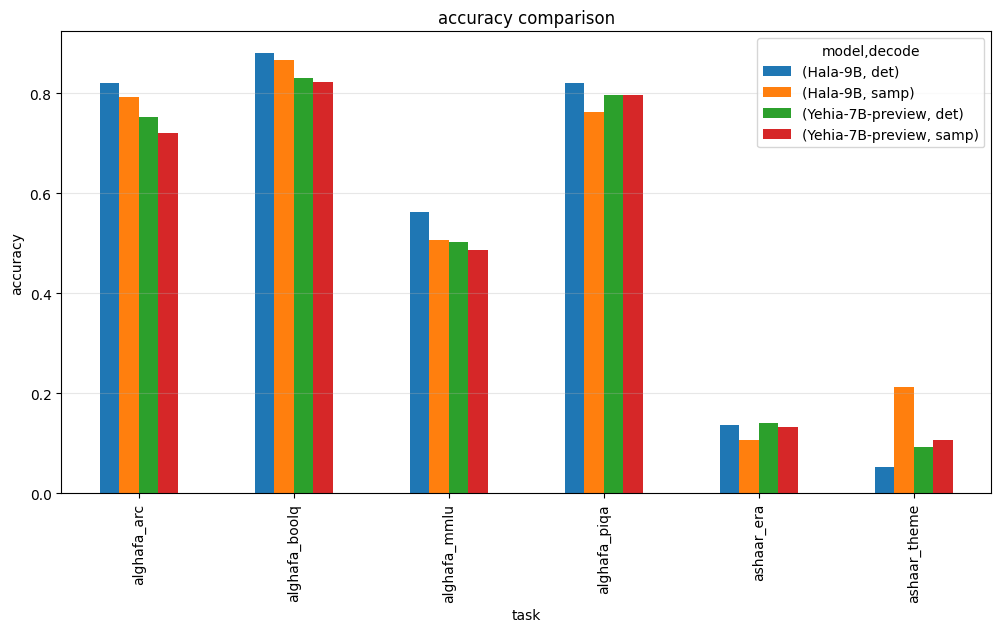

<Figure size 1200x600 with 0 Axes>

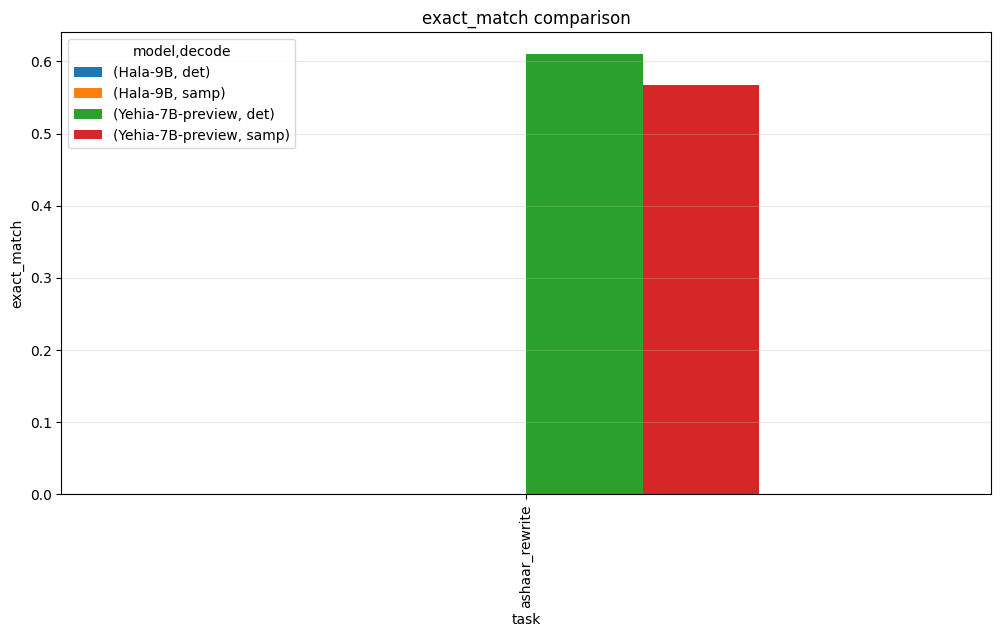

<Figure size 1200x600 with 0 Axes>

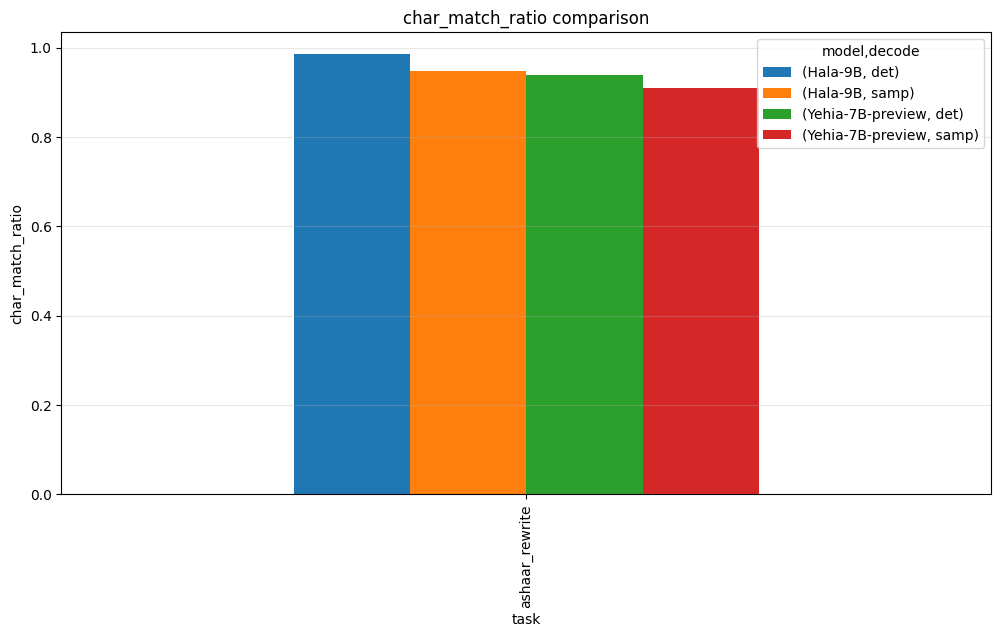

In [6]:
# %%
# ============================================================
# CELL 5 — Plots
# ============================================================
!pip install matplotlib
import matplotlib.pyplot as plt

for metric, table in comparison_tables.items():
    plt.figure(figsize=(12,6))
    table.plot(kind="bar", figsize=(12,6), title=f"{metric} comparison")
    plt.ylabel(metric)
    plt.grid(axis="y", alpha=0.3)
    plt.show()


In [8]:
# %%
# ============================================================
# CELL A — Compare failure/success pairs across the two models
# ============================================================

def find_disagreements(task):
    """
    Returns three DataFrames:
       1) rows where Hala failed AND Yehia succeeded
       2) rows where Hala succeeded AND Yehia failed
       3) rows where BOTH failed (for curiosity)
    """

    # Load all versions
    H_det  = loaded.get((task, "Hala-9B", "det"))
    H_samp = loaded.get((task, "Hala-9B", "samp"))
    Y_det  = loaded.get((task, "Yehia-7B-preview", "det"))
    Y_samp = loaded.get((task, "Yehia-7B-preview", "samp"))

    # Prefer deterministic runs for clean comparison
    H = H_det if H_det is not None else H_samp
    Y = Y_det if Y_det is not None else Y_samp

    if H is None or Y is None:
        print("Missing runs for task:", task)
        return None, None, None

    # Must share row_idx to compare
    if "row_idx" not in H.columns or "row_idx" not in Y.columns:
        print("Task missing row_idx:", task)
        return None, None, None

    merged = H.merge(Y, on="row_idx", suffixes=("_H", "_Y"))

    # classification tasks
    if "correct_H" in merged.columns and "correct_Y" in merged.columns:
        fail_H_ok_Y = merged[(merged["correct_H"] == 0) & (merged["correct_Y"] == 1)]
        ok_H_fail_Y = merged[(merged["correct_H"] == 1) & (merged["correct_Y"] == 0)]
        both_fail   = merged[(merged["correct_H"] == 0) & (merged["correct_Y"] == 0)]
        return fail_H_ok_Y, ok_H_fail_Y, both_fail

    # rewrite task (exact_match)
    if "exact_match_H" in merged.columns and "exact_match_Y" in merged.columns:
        fail_H_ok_Y = merged[(merged["exact_match_H"] == 0) & (merged["exact_match_Y"] == 1)]
        ok_H_fail_Y = merged[(merged["exact_match_H"] == 1) & (merged["exact_match_Y"] == 0)]
        both_fail   = merged[(merged["exact_match_H"] == 0) & (merged["exact_match_Y"] == 0)]
        return fail_H_ok_Y, ok_H_fail_Y, both_fail

    print("Unsupported task format:", task)
    return None, None, None


# 🔥 Example: show disagreements for Ashaar Theme
failH_okY, okH_failY, both_fail = find_disagreements("alghafa_arc")
'''
"alghafa_arc"

"alghafa_mmlu"

"alghafa_boolq"

"alghafa_piqa"

"ashaar_rewrite"

"ashaar_theme"

"ashaar_era"
'''
print("===== Hala FAILED, Yehia SUCCEEDED =====")
display(failH_okY.head(10))

print("===== Hala SUCCEEDED, Yehia FAILED =====")
display(okH_failY.head(10))

print("===== BOTH FAILED =====")
display(both_fail.head(10))


===== Hala FAILED, Yehia SUCCEEDED =====


,row_idx,question_H,sol1_H,sol2_H,sol3_H,sol4_H,gold_label_idx_H,pred_text_H,pred_label_idx_H,correct_H,question_Y,sol1_Y,sol2_Y,sol3_Y,sol4_Y,gold_label_idx_Y,pred_text_Y,pred_label_idx_Y,correct_Y
4,785,أي من هذه الأنشطة ستؤدي إلى تشكيل نوع مختلف من...,يتم ترك مسمار خارجًا حتى يصدأ.,تسقط زجاجة وتتشقق إلى قطع صغيرة.,يتم تمدد حزام مطاط حتى يُكسر.,يُحدّد القلم باتجاه حاد.,0,ج) يتم تمدد ح,2,0,أي من هذه الأنشطة ستؤدي إلى تشكيل نوع مختلف من...,يتم ترك مسمار خارجًا حتى يصدأ.,تسقط زجاجة وتتشقق إلى قطع صغيرة.,يتم تمدد حزام مطاط حتى يُكسر.,يُحدّد القلم باتجاه حاد.,0,أ,0,1
17,636,يريد الطلاب رفع درجة حرارة الماء في جرة زجاجية...,قشة في الماء.,غلاف بلاستيك شفاف حول الزجاج.,ميزان حرارة في الماء.,مادة سوداء حول الزجاج.,3,ب) غلاف بلاستيك,1,0,يريد الطلاب رفع درجة حرارة الماء في جرة زجاجية...,قشة في الماء.,غلاف بلاستيك شفاف حول الزجاج.,ميزان حرارة في الماء.,مادة سوداء حول الزجاج.,3,د,3,1
18,36,ما هو العنصر الذي يمكن إعادة استخدامه بأمان بع...,أدوات زجاجية استخدمت لتسخين السوائل,ورق الترشيح المستخدم لتصفية الماء,مناشف الورق المستخدمة لامتصاص الماء,المواد المسحوقة المنظفة من التسرب,0,د) المواد المسحوقة,3,0,ما هو العنصر الذي يمكن إعادة استخدامه بأمان بع...,أدوات زجاجية استخدمت لتسخين السوائل,ورق الترشيح المستخدم لتصفية الماء,مناشف الورق المستخدمة لامتصاص الماء,المواد المسحوقة المنظفة من التسرب,0,أ,0,1
19,723,ما الذي يصف التغيير الذي هو جسدي أكثر بدقة؟,تحول خيوط الصوف إلى سترة,تشغيل محرك الجرار,تآكل المعدن على الدراجة وتكون الصدأ,امتصاص العشب للطاقة من أشعة الشمس,0,ج) تآكل المعدن,2,0,ما الذي يصف التغيير الذي هو جسدي أكثر بدقة؟,تحول خيوط الصوف إلى سترة,تشغيل محرك الجرار,تآكل المعدن على الدراجة وتكون الصدأ,امتصاص العشب للطاقة من أشعة الشمس,0,أ,0,1
20,242,ما هو التشابه بين خلية الجلد لفأر والأميبا؟,كلاهما يحتاج إلى طاقة.,كلاهما ليس لديهما جدران خلوية.,كلاهما يتحركان باستخدام الأوبائيات الزيفية.,كلاهما يستهلكان ثاني أكسيد الكربون.,0,ج) كلاهما يتح,2,0,ما هو التشابه بين خلية الجلد لفأر والأميبا؟,كلاهما يحتاج إلى طاقة.,كلاهما ليس لديهما جدران خلوية.,كلاهما يتحركان باستخدام الأوبائيات الزيفية.,كلاهما يستهلكان ثاني أكسيد الكربون.,0,أ,0,1
41,1164,عند اشتعال مزيج من الأكسجين والهيدروجين في أنب...,الكتلة الإجمالية تزداد.,الكتلة الإجمالية تنخفض.,الكتلة الإجمالية تبقى كما هي.,جزء من الكتلة يتحول إلى طاقة حرارية.,2,د) جزء من الكتلة,3,0,عند اشتعال مزيج من الأكسجين والهيدروجين في أنب...,الكتلة الإجمالية تزداد.,الكتلة الإجمالية تنخفض.,الكتلة الإجمالية تبقى كما هي.,جزء من الكتلة يتحول إلى طاقة حرارية.,2,ج,2,1
44,683,ما هي الطاقة المتجددة البديلة التي تستخدم بشكل...,الطاقة الجيوثيرمالية,الطاقة النووية,الطاقة الكهرومائية,الوقود الحيوي,3,ج) الطاقة الكهرومائية,2,0,ما هي الطاقة المتجددة البديلة التي تستخدم بشكل...,الطاقة الجيوثيرمالية,الطاقة النووية,الطاقة الكهرومائية,الوقود الحيوي,3,د,3,1
58,1013,تحت أي ظرف ستكون التكيفات المساعدة التي تسمح ل...,عندما يحتاج اليرقات إلى السباحة على الفور,عندما يكون هناك كمية محدودة من الماء في بيئتهم,عندما يحدث انخفاض في عدد الحيوانات المفترسة,عندما يحتاج اليرقات للدمج مع بيئتها المحيطة,1,ج) عندما يحدث انخفاض,2,0,تحت أي ظرف ستكون التكيفات المساعدة التي تسمح ل...,عندما يحتاج اليرقات إلى السباحة على الفور,عندما يكون هناك كمية محدودة من الماء في بيئتهم,عندما يحدث انخفاض في عدد الحيوانات المفترسة,عندما يحتاج اليرقات للدمج مع بيئتها المحيطة,1,ب,1,1
60,50,ما الذي يصف صفة 12 المشتركة بين الأرض والقمر؟,لديهما تقريبًا نفس الغلاف الجوي.,لديهما تقريبًا نفس الجاذبية.,لديهما قشرة صخرية تشمل جبالًا.,لديهما مناطق تظهر بها تآكل كبير للمياه.,2,ب) لديهما تقريب,1,0,ما الذي يصف صفة 12 المشتركة بين الأرض والقمر؟,لديهما تقريبًا نفس الغلاف الجوي.,لديهما تقريبًا نفس الجاذبية.,لديهما قشرة صخرية تشمل جبالًا.,لديهما مناطق تظهر بها تآكل كبير للمياه.,2,ج,2,1
61,1069,من بين التالي، أي منها يحتوي على مجموعة تضم فق...,الأقمار والكواكب والمذنبات,الأقمار والمذنبات والنجوم,الكواكب والنجوم والمذنبات,الكواكب والنجوم والأقمار,0,ج) الكواكب والنج,2,0,من بين التالي، أي منها يحتوي على مجموعة تضم فق...,الأقمار والكواكب والمذنبات,الأقمار والمذنبات والنجوم,الكواكب والنجوم والمذنبات,الكواكب والنجوم والأقمار,0,أ,0,1


===== Hala SUCCEEDED, Yehia FAILED =====


,row_idx,question_H,sol1_H,sol2_H,sol3_H,sol4_H,gold_label_idx_H,pred_text_H,pred_label_idx_H,correct_H,question_Y,sol1_Y,sol2_Y,sol3_Y,sol4_Y,gold_label_idx_Y,pred_text_Y,pred_label_idx_Y,correct_Y
1,749,تغيرت أنواع الكائنات الحية على الأرض نتيجةً لز...,الإنتاج الأيضي للميثان,إنتاج النترات من النتروجين غير العضوي,تحليل المواد الكيميائية في وجه الأكسجين لإطلاق...,تحويل الطاقة الضوئية إلى الطاقة الكيميائية الر...,3,د) تحويل الطاقة الضو,3,1,تغيرت أنواع الكائنات الحية على الأرض نتيجةً لز...,الإنتاج الأيضي للميثان,إنتاج النترات من النتروجين غير العضوي,تحليل المواد الكيميائية في وجه الأكسجين لإطلاق...,تحويل الطاقة الضوئية إلى الطاقة الكيميائية الر...,3,ج,2,0
6,630,المرارة تخزن الصفراء، وهو سائل يساعد في هضم ال...,الفواكه,الحبوب,الجبن,الخضروات,2,ج) الجبن\n\nالشرح,2,1,المرارة تخزن الصفراء، وهو سائل يساعد في هضم ال...,الفواكه,الحبوب,الجبن,الخضروات,2,د,3,0
13,133,تزود التلفاز بعض المزايا، ما هو طريقة واحدة يس...,تستخدم صناعة التلفاز العديد من المواد الكيميائ...,تعرض الإعلانات التلفزيونية العديد من الألعاب ا...,يوفر التلفزيون معلومات عن الحالة الجوية الحالية.,استخدام الكهرباء لتشغيل التلفزيونات هو استخدام...,2,ج) يوفر التلفزيون,2,1,تزود التلفاز بعض المزايا، ما هو طريقة واحدة يس...,تستخدم صناعة التلفاز العديد من المواد الكيميائ...,تعرض الإعلانات التلفزيونية العديد من الألعاب ا...,يوفر التلفزيون معلومات عن الحالة الجوية الحالية.,استخدام الكهرباء لتشغيل التلفزيونات هو استخدام...,2,ب,1,0
21,943,ما هي التحقيق الأفضل لاختبار تأثير الجاذبية عل...,أقلام الرصاص تسقط من نفس الارتفاع,بالونات تطفو لأعلى من نفس الارتفاع,دراجة تسرع على سطح مستوٍ,كرة تبطئ على سطح مستوٍ,0,أ) أقلام الرصاص تس,0,1,ما هي التحقيق الأفضل لاختبار تأثير الجاذبية عل...,أقلام الرصاص تسقط من نفس الارتفاع,بالونات تطفو لأعلى من نفس الارتفاع,دراجة تسرع على سطح مستوٍ,كرة تبطئ على سطح مستوٍ,0,د,3,0
39,402,بعض الحيوانات تعيش في السهول العشبية. يحرق حري...,تلك التي تأكل اللحوم,تلك التي تستخدم النباتات كمأوى,تلك التي تعيش تحت الأرض,تلك التي تبني أعشاشًا على الأرض,2,ج) تلك التي تعيش تحت,2,1,بعض الحيوانات تعيش في السهول العشبية. يحرق حري...,تلك التي تأكل اللحوم,تلك التي تستخدم النباتات كمأوى,تلك التي تعيش تحت الأرض,تلك التي تبني أعشاشًا على الأرض,2,أ,0,0
43,25,ما هي كتلة ذرة الكربون التي تحتوي على 6 بروتون...,6,7,13,19,2,ج) 13\n\nالش,2,1,ما هي كتلة ذرة الكربون التي تحتوي على 6 بروتون...,6,7,13,19,2,د,3,0
55,1082,يتم زراعة بعض أنواع الأسماك المعروضة للبيع في ...,أصحاب محلات البقالة,سائقو الشاحنات الذين يقلون الأسماك,أصحاب متاجر بيع الأسماك المستخرجة من البحر,عمال البناء الذين يقومون ببناء المزارع,2,ج) أصحاب متاجر,2,1,يتم زراعة بعض أنواع الأسماك المعروضة للبيع في ...,أصحاب محلات البقالة,سائقو الشاحنات الذين يقلون الأسماك,أصحاب متاجر بيع الأسماك المستخرجة من البحر,عمال البناء الذين يقومون ببناء المزارع,2,د,3,0
64,722,دراجة هوائية تسير بسرعة 3 أمتار في الثانية الو...,-1 م / ث²,-6 م / ث²,3 م / ث²,9 م / ث²,0,أ) -1 م / ث,0,1,دراجة هوائية تسير بسرعة 3 أمتار في الثانية الو...,-1 م / ث²,-6 م / ث²,3 م / ث²,9 م / ث²,0,ب,1,0
68,536,شخص يركب في عجلة فوضوية متحركة يتغير باستمرار,الكتلة.,السرعة.,القوة الصافية.,معدل الدوران.,2,ج) القوة الصافية.,2,1,شخص يركب في عجلة فوضوية متحركة يتغير باستمرار,الكتلة.,السرعة.,القوة الصافية.,معدل الدوران.,2,د,3,0
74,160,ما الذي يمكن العثور عليه في الأرض والقمر معًا؟,التلال,الغلاف الجوي الكثيف,العواصف الرعدية,المحيطات,0,أ) التلال\n\nالشرح,0,1,ما الذي يمكن العثور عليه في الأرض والقمر معًا؟,التلال,الغلاف الجوي الكثيف,العواصف الرعدية,المحيطات,0,د,3,0


===== BOTH FAILED =====


,row_idx,question_H,sol1_H,sol2_H,sol3_H,sol4_H,gold_label_idx_H,pred_text_H,pred_label_idx_H,correct_H,question_Y,sol1_Y,sol2_Y,sol3_Y,sol4_Y,gold_label_idx_Y,pred_text_Y,pred_label_idx_Y,correct_Y
7,801,وفقًا لتصنيف الخلايا، تُفرّق الخلايا الإلكترون...,عمليات الحياة,اختلاف الحجم,أغشية البلازما,جزيئات الطاقة,1,د) جزيئات الطاقة,3,0,وفقًا لتصنيف الخلايا، تُفرّق الخلايا الإلكترون...,عمليات الحياة,اختلاف الحجم,أغشية البلازما,جزيئات الطاقة,1,ج,2,0
11,871,كيف يمكن لسجلات التحقيق أن تكون أكثر فائدة؟,توفر السجلات دلائل على الأخطاء التي تم ارتكابه...,تثبت السجلات أن التحقيق تم إجراؤه عدة مرات.,تستبعد السجلات الحاجة لتكرار التحقيق.,تجعل السجلات النتائج التي توصل إليها التحقيق د...,0,ج) تستبعد السجلات,2,0,كيف يمكن لسجلات التحقيق أن تكون أكثر فائدة؟,توفر السجلات دلائل على الأخطاء التي تم ارتكابه...,تثبت السجلات أن التحقيق تم إجراؤه عدة مرات.,تستبعد السجلات الحاجة لتكرار التحقيق.,تجعل السجلات النتائج التي توصل إليها التحقيق د...,0,ج,2,0
50,629,كم عنصرًا في المركب Mg(OH)₂؟,2,3,4,5,1,ج) 4\n\nالشرح,2,0,كم عنصرًا في المركب Mg(OH)₂؟,2,3,4,5,1,ج,2,0
65,1143,يُعَدّ ضوء الشمس المستخدم لتسخين المياه بالطاق...,اصطناعيًا.,متجددًا.,لا يُنَفَّذُ.,غير متجدد.,2,ب) متجددًا.,1,0,يُعَدّ ضوء الشمس المستخدم لتسخين المياه بالطاق...,اصطناعيًا.,متجددًا.,لا يُنَفَّذُ.,غير متجدد.,2,ب,1,0
69,136,الزنك هو معدن يساعد,في الحفاظ على توازن الماء في الخلايا.,في منع تسوس الأسنان.,في شفاء الجروح والخدوش.,في نقل الأكسجين في الدم.,2,ب) في منع تسوس الأس,1,0,الزنك هو معدن يساعد,في الحفاظ على توازن الماء في الخلايا.,في منع تسوس الأسنان.,في شفاء الجروح والخدوش.,في نقل الأكسجين في الدم.,2,ب,1,0
111,61,يخلط الطالب الخل والصودا الحمضية لاستخدامها في...,تغير الطاقة الضوئية إلى طاقة حرارية,تحولت الطاقة الحرارية إلى طاقة كيميائية,تحولت الطاقة الكيميائية إلى طاقة حرارية,تحولت الطاقة الكيميائية إلى طاقة ضوئية,1,ج) تحولت الطاقة الكيم,2,0,يخلط الطالب الخل والصودا الحمضية لاستخدامها في...,تغير الطاقة الضوئية إلى طاقة حرارية,تحولت الطاقة الحرارية إلى طاقة كيميائية,تحولت الطاقة الكيميائية إلى طاقة حرارية,تحولت الطاقة الكيميائية إلى طاقة ضوئية,1,ج,2,0
113,393,في أي المجالات يمكن العثور على الكائنات الحية ...,العوائل الحقيقية والحقيقية النووية,البكتيريا والحقيقية النووية,العوائل الحقيقية والبكتيريا,العوائل الحقيقية والبكتيريا والحقيقية النووية,1,د) العوائل الحقيق,3,0,في أي المجالات يمكن العثور على الكائنات الحية ...,العوائل الحقيقية والحقيقية النووية,البكتيريا والحقيقية النووية,العوائل الحقيقية والبكتيريا,العوائل الحقيقية والبكتيريا والحقيقية النووية,1,د,3,0
118,824,ما هو مثال على سلوك تعلّم؟,يصطاد النمر الغزال.,تهرب الفأر من الكويوت.,يسبح السمكة السلمون في النهر.,يطرق النحات الخشب للبحث عن الحشرات.,0,د) يطرق النحات,3,0,ما هو مثال على سلوك تعلّم؟,يصطاد النمر الغزال.,تهرب الفأر من الكويوت.,يسبح السمكة السلمون في النهر.,يطرق النحات الخشب للبحث عن الحشرات.,0,ب,1,0
124,778,الجسيمات داخل مادة ما في حركة مستمرة. ما هي ال...,شمع الشموع عند درجة حرارة الغرفة,الماء في كوب من ماء الثلج,البخار من فنجان قهوة,مكعب الثلج في كوب من الشاي,3,ب) الماء في كوب من م,1,0,الجسيمات داخل مادة ما في حركة مستمرة. ما هي ال...,شمع الشموع عند درجة حرارة الغرفة,الماء في كوب من ماء الثلج,البخار من فنجان قهوة,مكعب الثلج في كوب من الشاي,3,ب,1,0
132,563,ما هي النظرية الخاصة بأصل القمر التي تشير إلى ...,نظرية الاصطدام العملاق,نظرية الانشطار,نظرية الاصطياد,نظرية الازدواجية,3,ج) نظرية الاصطياد,2,0,ما هي النظرية الخاصة بأصل القمر التي تشير إلى ...,نظرية الاصطدام العملاق,نظرية الانشطار,نظرية الاصطياد,نظرية الازدواجية,3,أ,0,0


'\n"alghafa_arc"\n\n"alghafa_mmlu"\n\n"alghafa_boolq"\n\n"alghafa_piqa"\n\n"ashaar_rewrite"\n\n"ashaar_theme"\n\n"ashaar_era"\n'

In [9]:
# %%
# ============================================================
# CELL B — Show all failures for Yehia
# ============================================================

def yehia_failures(task):
    df_det  = loaded.get((task, "Yehia-7B-preview", "det"))
    df_samp = loaded.get((task, "Yehia-7B-preview", "samp"))

    df = df_det if df_det is not None else df_samp
    if df is None:
        print("Missing Yehia for task:", task)
        return pd.DataFrame()

    # For MCQ & theme/era classification
    if "correct" in df.columns:
        return df[df["correct"] == 0]

    # For rewrite
    if "exact_match" in df.columns:
        return df[df["exact_match"] == 0]

    return pd.DataFrame()


# 🔥 Example: Yehia failures for ARC
fail_y = yehia_failures("alghafa_arc")
'''
"alghafa_arc"

"alghafa_mmlu"

"alghafa_boolq"

"alghafa_piqa"

"ashaar_rewrite"

"ashaar_theme"

"ashaar_era"
'''
print("Yehia failures:", len(fail_y))
display(fail_y.head(10))


Yehia failures: 74


,row_idx,question,sol1,sol2,sol3,sol4,gold_label_idx,pred_text,pred_label_idx,correct
1,749,تغيرت أنواع الكائنات الحية على الأرض نتيجةً لز...,الإنتاج الأيضي للميثان,إنتاج النترات من النتروجين غير العضوي,تحليل المواد الكيميائية في وجه الأكسجين لإطلاق...,تحويل الطاقة الضوئية إلى الطاقة الكيميائية الر...,3,ج,2,0
6,630,المرارة تخزن الصفراء، وهو سائل يساعد في هضم ال...,الفواكه,الحبوب,الجبن,الخضروات,2,د,3,0
7,801,وفقًا لتصنيف الخلايا، تُفرّق الخلايا الإلكترون...,عمليات الحياة,اختلاف الحجم,أغشية البلازما,جزيئات الطاقة,1,ج,2,0
11,871,كيف يمكن لسجلات التحقيق أن تكون أكثر فائدة؟,توفر السجلات دلائل على الأخطاء التي تم ارتكابه...,تثبت السجلات أن التحقيق تم إجراؤه عدة مرات.,تستبعد السجلات الحاجة لتكرار التحقيق.,تجعل السجلات النتائج التي توصل إليها التحقيق د...,0,ج,2,0
13,133,تزود التلفاز بعض المزايا، ما هو طريقة واحدة يس...,تستخدم صناعة التلفاز العديد من المواد الكيميائ...,تعرض الإعلانات التلفزيونية العديد من الألعاب ا...,يوفر التلفزيون معلومات عن الحالة الجوية الحالية.,استخدام الكهرباء لتشغيل التلفزيونات هو استخدام...,2,ب,1,0
21,943,ما هي التحقيق الأفضل لاختبار تأثير الجاذبية عل...,أقلام الرصاص تسقط من نفس الارتفاع,بالونات تطفو لأعلى من نفس الارتفاع,دراجة تسرع على سطح مستوٍ,كرة تبطئ على سطح مستوٍ,0,د,3,0
39,402,بعض الحيوانات تعيش في السهول العشبية. يحرق حري...,تلك التي تأكل اللحوم,تلك التي تستخدم النباتات كمأوى,تلك التي تعيش تحت الأرض,تلك التي تبني أعشاشًا على الأرض,2,أ,0,0
43,25,ما هي كتلة ذرة الكربون التي تحتوي على 6 بروتون...,6,7,13,19,2,د,3,0
50,629,كم عنصرًا في المركب Mg(OH)₂؟,2,3,4,5,1,ج,2,0
55,1082,يتم زراعة بعض أنواع الأسماك المعروضة للبيع في ...,أصحاب محلات البقالة,سائقو الشاحنات الذين يقلون الأسماك,أصحاب متاجر بيع الأسماك المستخرجة من البحر,عمال البناء الذين يقومون ببناء المزارع,2,د,3,0


In [ ]:
# %%
# ============================================================
# CELL C — Show all failures for Hala
# ============================================================

def hala_failures(task):
    df_det  = loaded.get((task, "Hala-9B", "det"))
    df_samp = loaded.get((task, "Hala-9B", "samp"))

    df = df_det if df_det is not None else df_samp
    if df is None:
        print("Missing Hala for task:", task)
        return pd.DataFrame()

    # Classification tasks
    if "correct" in df.columns:
        return df[df["correct"] == 0]

    # Rewrite task
    if "exact_match" in df.columns:
        return df[df["exact_match"] == 0]

    return pd.DataFrame()


# 🔥 Example: Hala failures for Ashaar Era
fail_h = hala_failures("ashaar_era")
'''
"alghafa_arc"

"alghafa_mmlu"

"alghafa_boolq"

"alghafa_piqa"

"ashaar_rewrite"

"ashaar_theme"

"ashaar_era"
'''
print("Hala failures:", len(fail_h))
display(fail_h.head(10))


/tmp/ipykernel_4059/349719173.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agg, x="model_decode", y="value", palette="deep")


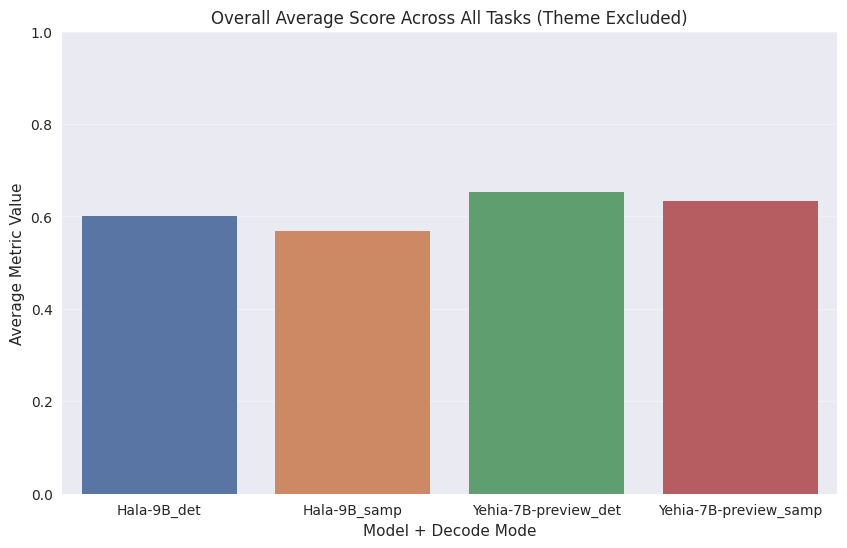

In [12]:
# %%
# ============================================================
# CELL D — Histograms of model performance (EXCLUDE THEME)
# ============================================================

!pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

# Exclude the theme task
filtered = summary_df[summary_df["task"] != "ashaar_theme"]

# Aggregate across tasks
agg = filtered.groupby(["model", "decode"]).agg({"value": "mean"}).reset_index()
agg["model_decode"] = agg["model"] + "_" + agg["decode"]

plt.figure(figsize=(10,6))
sns.barplot(data=agg, x="model_decode", y="value", palette="deep")
plt.title("Overall Average Score Across All Tasks (Theme Excluded)")
plt.ylabel("Average Metric Value")
plt.xlabel("Model + Decode Mode")
plt.ylim(0,1)
plt.grid(axis="y", alpha=0.3)
plt.show()
